In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.tools import diff
from statsmodels.graphics.tsaplots import month_plot
from statsmodels.tsa.stattools import acf,pacf, adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from time import time
from datetime import timedelta
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from pandas.plotting import lag_plot
!pip install pmdarima
from pmdarima import auto_arima
import copy
import warnings
warnings.filterwarnings('ignore')

In [2]:
data=pd.read_csv("SeoulBikeData.csv")
data.head(10)

,Date,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,01/12/2017,254,0,-5.2,37,2.2,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes
1,01/12/2017,204,1,-5.5,38,0.8,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes
2,01/12/2017,173,2,-6.0,39,1.0,2000,-17.7,0.00,0.0,0.0,Winter,No Holiday,Yes
3,01/12/2017,107,3,-6.2,40,0.9,2000,-17.6,0.00,0.0,0.0,Winter,No Holiday,Yes
4,01/12/2017,78,4,-6.0,36,2.3,2000,-18.6,0.00,0.0,0.0,Winter,No Holiday,Yes
5,01/12/2017,100,5,-6.4,37,1.5,2000,-18.7,0.00,0.0,0.0,Winter,No Holiday,Yes
6,01/12/2017,181,6,-6.6,35,1.3,2000,-19.5,0.00,0.0,0.0,Winter,No Holiday,Yes
7,01/12/2017,460,7,-7.4,38,0.9,2000,-19.3,0.00,0.0,0.0,Winter,No Holiday,Yes
8,01/12/2017,930,8,-7.6,37,1.1,2000,-19.8,0.01,0.0,0.0,Winter,No Holiday,Yes
9,01/12/2017,490,9,-6.5,27,0.5,1928,-22.4,0.23,0.0,0.0,Winter,No Holiday,Yes


## Data Preprocessing

In [3]:
data.dtypes

,0
Date,object
Rented Bike Count,int64
Hour,int64
Temperature(C),float64
Humidity(%),int64
Wind speed (m/s),float64
Visibility (10m),int64
Dew point temperature(C),float64
Solar Radiation (MJ/m2),float64
Rainfall(mm),float64


In [4]:
data.isna().sum()

,0
Date,0
Rented Bike Count,0
Hour,0
Temperature(C),0
Humidity(%),0
Wind speed (m/s),0
Visibility (10m),0
Dew point temperature(C),0
Solar Radiation (MJ/m2),0
Rainfall(mm),0


In [5]:
data.describe()

,Rented Bike Count,Hour,Temperature(C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm)
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.500000,12.882922,58.226256,1.724909,1436.825799,4.073813,0.569111,0.148687,0.075068
std,644.997468,6.922582,11.944825,20.362413,1.036300,608.298712,13.060369,0.868746,1.128193,0.436746
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,-30.600000,0.000000,0.000000,0.000000
25%,191.000000,5.750000,3.500000,42.000000,0.900000,940.000000,-4.700000,0.000000,0.000000,0.000000
50%,504.500000,11.500000,13.700000,57.000000,1.500000,1698.000000,5.100000,0.010000,0.000000,0.000000
75%,1065.250000,17.250000,22.500000,74.000000,2.300000,2000.000000,14.800000,0.930000,0.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,27.200000,3.520000,35.000000,8.800000


In [6]:
data["Date"]=pd.to_datetime(data["Date"],format="%d/%m/%Y")
data["Date"]=data["Date"]+pd.to_timedelta(data["Hour"],unit="h")
data=data.set_index(data["Date"])
categorical_cols=["Seasons","Holiday","Functioning Day"]
data[categorical_cols]=data[categorical_cols].astype("category")
for col in categorical_cols:
  print("Column: "+ col+": "+str(data[col].unique()))

data=pd.get_dummies(data,columns=["Seasons"],dtype=int)
holiday_map={"Holiday":0,"No Holiday":1}
functioning_day_map={"Yes":1,"No":0}
data["Holiday"]=data["Holiday"].map(holiday_map)
data["Functioning Day"]=data["Functioning Day"].map(functioning_day_map)

columns_renamed={"Rented Bike Count":"target","Temperature(C)":"temp","Humidity(%)":"hum","Wind speed (m/s)":"wind","Visibility (10m)":"vis",
                 "Dew point temperature(C)":"dew","Solar Radiation (MJ/m2)":"solar","Rainfall(mm)":"rain","Snowfall (cm)":"snow","Holiday":"holiday",
                 "Functioning Day":"func","Seasons_Autumn":"s_autumn","Seasons_Spring":"s_spring","Seasons_Summer":"s_summer","Seasons_Winter":"s_winter"}
data=data.rename(columns=columns_renamed)
data=data[[columns_renamed[old_column_name] for old_column_name in columns_renamed.keys()]]
data.dtypes

Column: Seasons: ['Winter', 'Spring', 'Summer', 'Autumn']
Categories (4, object): ['Autumn', 'Spring', 'Summer', 'Winter']
Column: Holiday: ['No Holiday', 'Holiday']
Categories (2, object): ['Holiday', 'No Holiday']
Column: Functioning Day: ['Yes', 'No']
Categories (2, object): ['No', 'Yes']


,0
target,int64
temp,float64
hum,int64
wind,float64
vis,int64
dew,float64
solar,float64
rain,float64
snow,float64
holiday,category


In [7]:
data.head()

,target,temp,hum,wind,vis,dew,solar,rain,snow,holiday,func,s_autumn,s_spring,s_summer,s_winter
Date,,,,,,,,,,,,,,,
2017-12-01 00:00:00,254,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,1,1,0,0,0,1
2017-12-01 01:00:00,204,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,1,1,0,0,0,1
2017-12-01 02:00:00,173,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,1,1,0,0,0,1
2017-12-01 03:00:00,107,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,1,1,0,0,0,1
2017-12-01 04:00:00,78,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,1,1,0,0,0,1


In [8]:
print("Min Date: "+str(data.index.min()))
print("Max Date: "+str(data.index.max()))

Min Date: 2017-12-01 00:00:00
Max Date: 2018-11-30 23:00:00


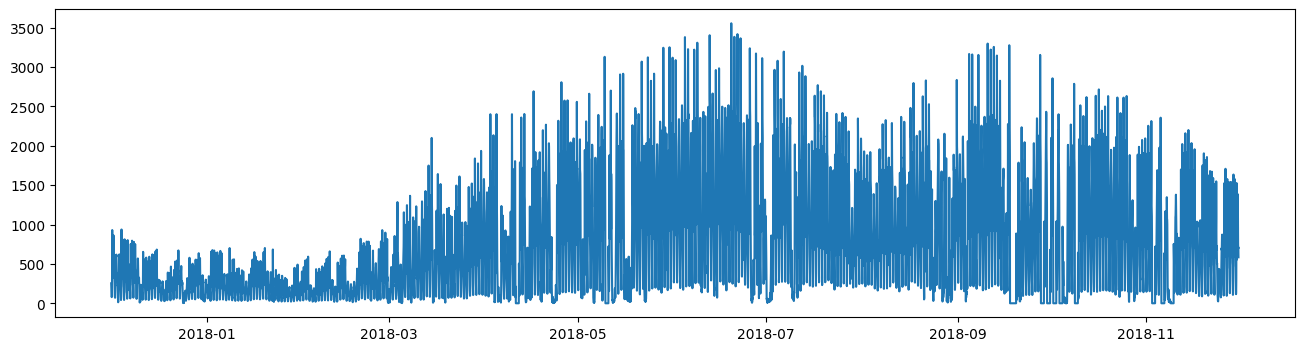

In [9]:
plt.figure(figsize=(16,4))
plt.plot(data["target"])

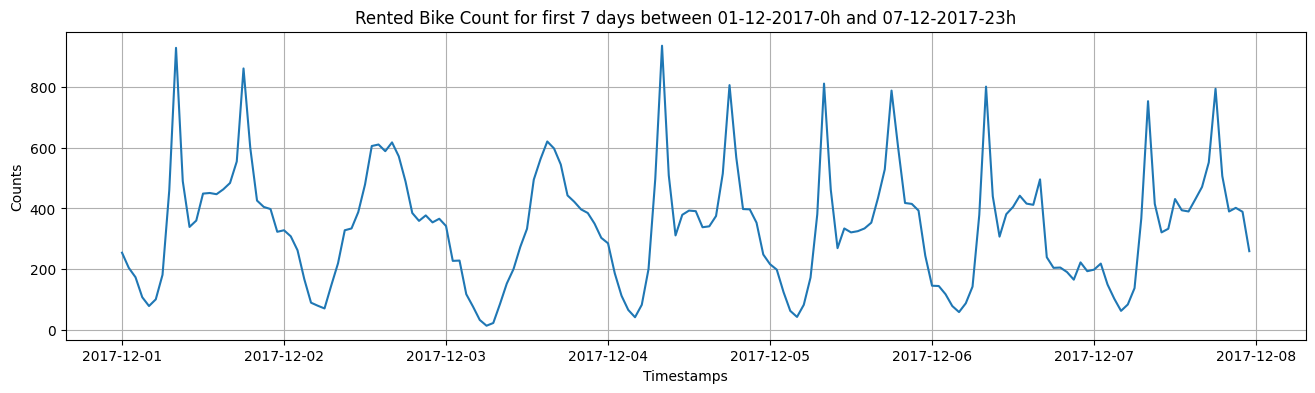

In [10]:
plt.figure(figsize=(16,4))
plt.plot(data["target"][:7*24])
plt.title("Rented Bike Count for first 7 days between 01-12-2017-0h and 07-12-2017-23h")
plt.xlabel("Timestamps")
plt.ylabel("Counts")
plt.grid(True)

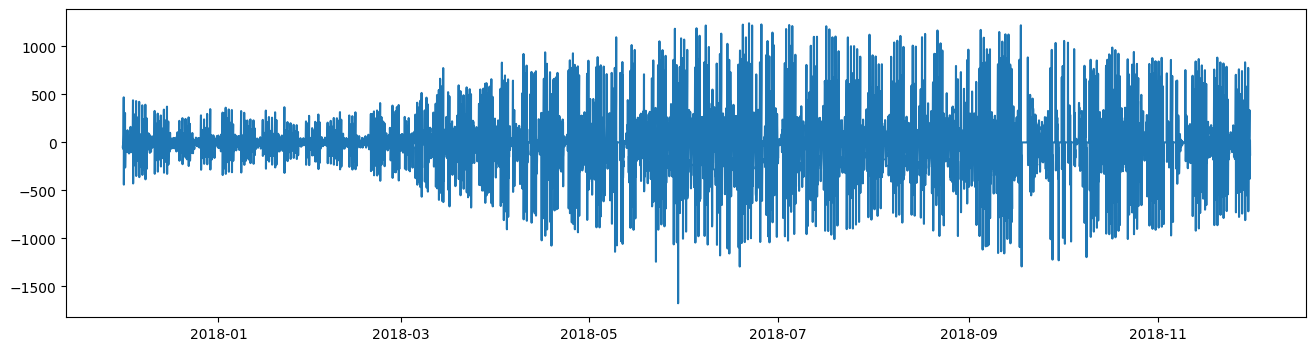

In [11]:
data["first_diff"]=data["target"].diff()
plt.figure(figsize=(16,4))
plt.plot(data["first_diff"][1:])

In [12]:
adf_test=adfuller(data["first_diff"][1:])
print(f'ADF Statistic: {adf_test[0]}')
print(f'p-value: {adf_test[1]}')
print(f'Critical Values: {adf_test[4]}')

ADF Statistic: -22.061339014760847
p-value: 0.0
Critical Values: {'1%': np.float64(-3.4311000545606776), '5%': np.float64(-2.861871474145309), '10%': np.float64(-2.566946438722175)}


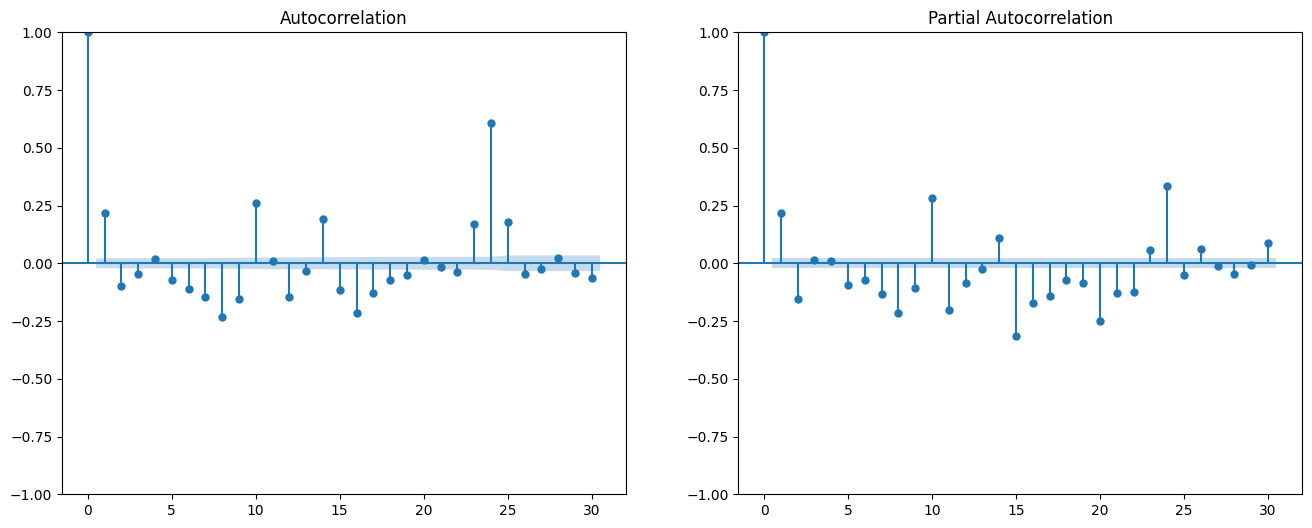

In [13]:
fig, ax=plt.subplots(1,2,figsize=(16,6))
plot_acf(data["first_diff"][1:],lags=30,ax=ax[0])
plot_pacf(data["first_diff"][1:],lags=30,ax=ax[1])
plt.show()

In [14]:
train_data=data.iloc[1:data.shape[0]-24]
test_data=data.iloc[-24:]
print(train_data.shape)
print(test_data.shape)

(8735, 16)
(24, 16)


## Include Regression Terms

In [15]:
scaling_columns=['temp','hum','wind','vis','dew','solar','rain','snow']
scaler=MinMaxScaler()
train_data[scaling_columns]=scaler.fit_transform(train_data[scaling_columns])
test_data[scaling_columns]=scaler.transform(test_data[scaling_columns])
train_data.head()

,target,temp,hum,wind,vis,dew,solar,rain,snow,holiday,func,s_autumn,s_spring,s_summer,s_winter,first_diff
Date,,,,,,,,,,,,,,,,
2017-12-01 01:00:00,204,0.215035,0.387755,0.108108,1.0,0.224913,0.0,0.0,0.0,1,1,0,0,0,1,-50.0
2017-12-01 02:00:00,173,0.206294,0.397959,0.135135,1.0,0.223183,0.0,0.0,0.0,1,1,0,0,0,1,-31.0
2017-12-01 03:00:00,107,0.202797,0.408163,0.121622,1.0,0.224913,0.0,0.0,0.0,1,1,0,0,0,1,-66.0
2017-12-01 04:00:00,78,0.206294,0.367347,0.310811,1.0,0.207612,0.0,0.0,0.0,1,1,0,0,0,1,-29.0
2017-12-01 05:00:00,100,0.199301,0.377551,0.202703,1.0,0.205882,0.0,0.0,0.0,1,1,0,0,0,1,22.0


In [16]:
exog_columns=scaling_columns+['holiday','func','s_autumn','s_spring','s_summer','s_winter']

In [17]:
# non_seasonal_orders=(1,0,0)
# seasonal_orders=(1,1,0,24)
non_seasonal_orders=(1,1,0)
seasonal_orders=(1,0,0,24)

In [18]:
# Without Exog Columns
ts_model_sarimax_without_exog=SARIMAX(train_data["target"],order=non_seasonal_orders,seasonal_order=seasonal_orders)

start=time()
model_fit_sarimax_without_exog=ts_model_sarimax_without_exog.fit()
end=time()
print("Model Fitting Time: ", end-start)
print(model_fit_sarimax_without_exog.summary())

Model Fitting Time:  17.536531925201416
                                     SARIMAX Results                                      
Dep. Variable:                             target   No. Observations:                 8735
Model:             SARIMAX(1, 1, 0)x(1, 0, 0, 24)   Log Likelihood              -59623.771
Date:                            Tue, 05 May 2026   AIC                         119253.542
Time:                                    18:30:10   BIC                         119274.767
Sample:                                12-01-2017   HQIC                        119260.775
                                     - 11-29-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1441      0.005     28.915      0.000       0.134       0

In [19]:
predictions_sarimax_without_exog=model_fit_sarimax_without_exog.forecast(len(test_data))
predictions_sarimax_without_exog=pd.Series(predictions_sarimax_without_exog,index=test_data.index)
residuals_sarimax_without_exog=test_data["target"]-predictions_sarimax_without_exog

Text(0.5, 1.0, 'Residuals Plot')

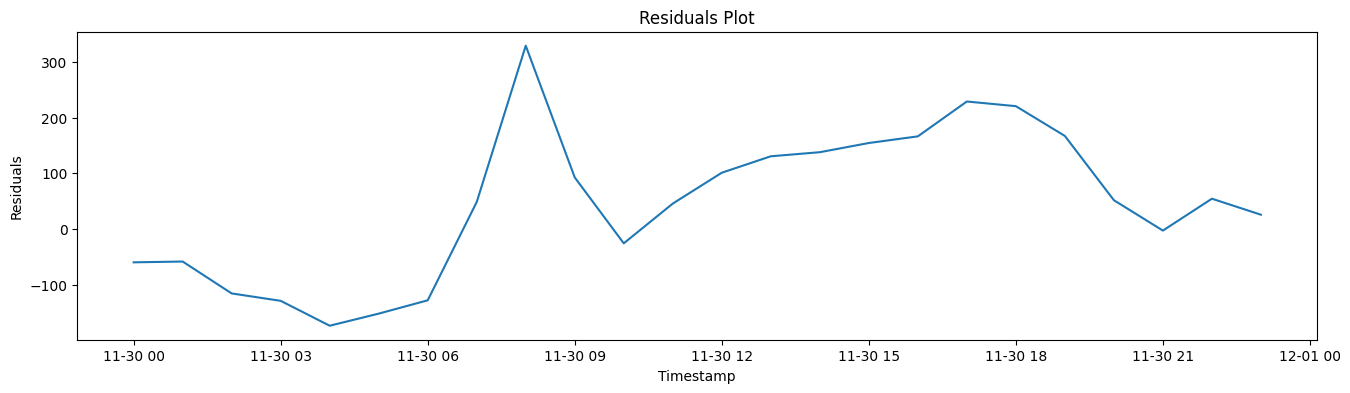

In [20]:
plt.figure(figsize=(16,4))
plt.plot(residuals_sarimax_without_exog)
plt.ylabel("Residuals")
plt.xlabel("Timestamp")
plt.title("Residuals Plot")

Text(0, 0.5, 'Target')

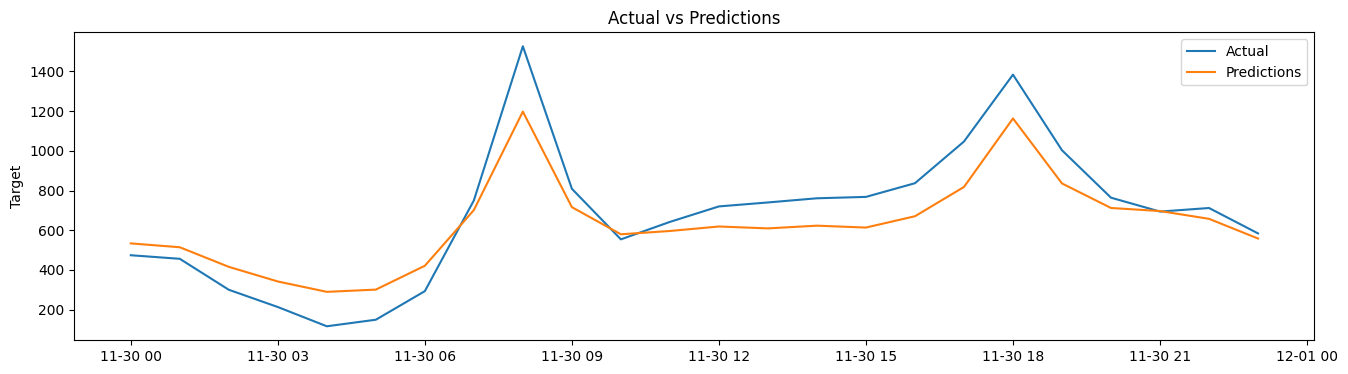

In [21]:
plt.figure(figsize=(16,4))
plt.plot(test_data["target"])
plt.plot(predictions_sarimax_without_exog)
plt.legend(('Actual','Predictions'))
plt.title('Actual vs Predictions')
plt.ylabel('Target')

In [22]:
# print('Mean Absolute Percent Error:', round(np.mean(abs(residuals_sarimax/test_data["first_diff"])),4))
print('Mean Absolute Percent Error:', round(np.mean(abs(residuals_sarimax_without_exog/test_data["target"])),4))
print('Root Mean Squared Error:', np.sqrt(np.mean(residuals_sarimax_without_exog**2)))

Mean Absolute Percent Error: 0.2643
Root Mean Squared Error: 138.72312490039184


In [23]:
print(test_data["target"].shape)
result_without_exog=pd.DataFrame({"Actual":test_data["target"],"Predicted without Exog":predictions_sarimax_without_exog},index=test_data.index)
result_without_exog

(24,)


,Actual,Predicted without Exog
Date,,
2018-11-30 00:00:00,474,533.675050
2018-11-30 01:00:00,456,514.258323
2018-11-30 02:00:00,300,415.522714
2018-11-30 03:00:00,213,341.802666
2018-11-30 04:00:00,116,289.489844
2018-11-30 05:00:00,149,300.784233
2018-11-30 06:00:00,293,420.863202
2018-11-30 07:00:00,750,701.443816
2018-11-30 08:00:00,1527,1197.809952


In [24]:
# Check multicollinearity in exog variables


## With all the Exogenous variables

In [25]:
# smodel=auto_arima(train_data["target"],start_p=2,start_q=2,max_p=2,max_q=2,m=24,start_P=0,start_Q=0,max_P=1,max_Q=1,seasonal=True,d=1,D=1,exogenous=test_data[exog_columns],trace=True,error_action='ignore',suppress_warnings=True,stepwise=True)
# smodel.summary()

In [26]:
# non_seasonal_orders_with_exog_all=(1,0,0)
# seasonal_orders_with_exog_all=(1,1,0,24)
non_seasonal_orders_with_exog_all=(1,1,0)
seasonal_orders_with_exog_all=(1,0,0,24)

In [27]:
# With All Exog Columns
ts_model_sarimax_with_exog_all=SARIMAX(train_data["target"],order=non_seasonal_orders_with_exog_all,seasonal_order=seasonal_orders_with_exog_all,exog=train_data[exog_columns])

start=time()
model_fit_sarimax_with_exog_all=ts_model_sarimax_with_exog_all.fit()
end=time()
print("Model Fitting Time: ", end-start)
print(model_fit_sarimax_with_exog_all.summary())

Model Fitting Time:  92.92391610145569
                                     SARIMAX Results                                      
Dep. Variable:                             target   No. Observations:                 8735
Model:             SARIMAX(1, 1, 0)x(1, 0, 0, 24)   Log Likelihood              -59393.834
Date:                            Tue, 05 May 2026   AIC                         118821.667
Time:                                    18:31:45   BIC                         118941.942
Sample:                                12-01-2017   HQIC                        118862.655
                                     - 11-29-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp        3661.9837    213.214     17.175      0.000    3244.092    4079.

In [28]:
predictions_sarimax_with_exog_all=model_fit_sarimax_with_exog_all.forecast(len(test_data),exog=test_data[exog_columns])
predictions_sarimax_with_exog_all=pd.Series(predictions_sarimax_with_exog_all,index=test_data.index)
residuals_sarimax_with_exog_all=test_data["target"]-predictions_sarimax_with_exog_all

Text(0.5, 1.0, 'Residuals Plot')

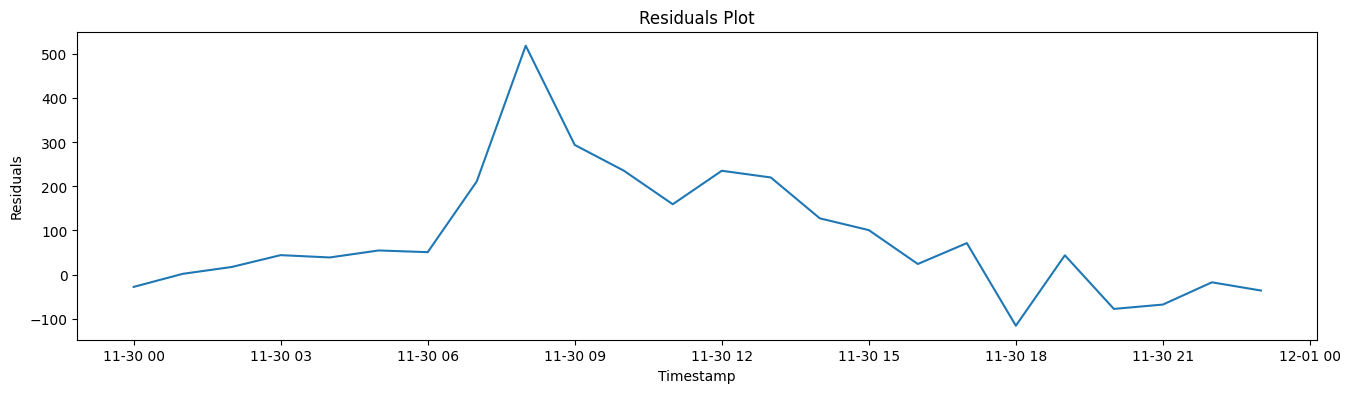

In [29]:
plt.figure(figsize=(16,4))
plt.plot(residuals_sarimax_with_exog_all)
plt.ylabel("Residuals")
plt.xlabel("Timestamp")
plt.title("Residuals Plot")

Text(0, 0.5, 'Target')

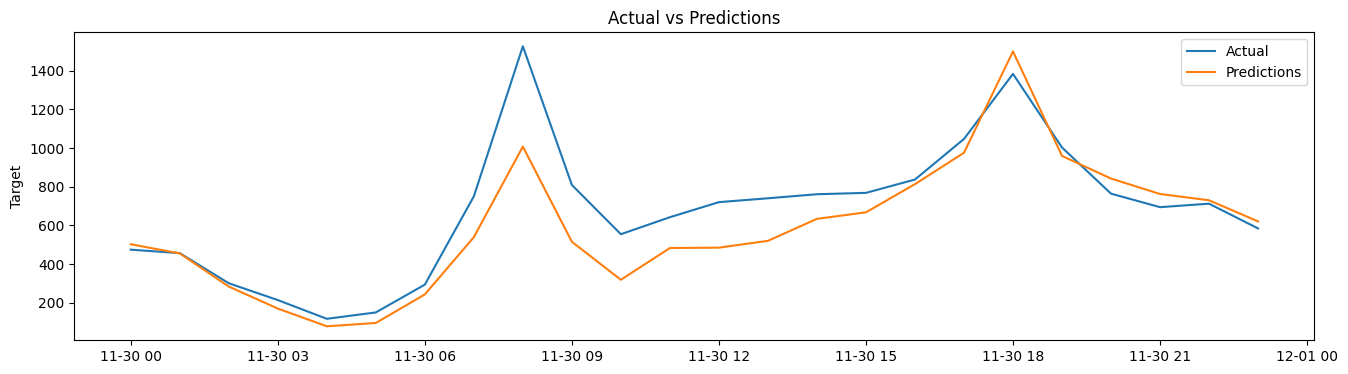

In [30]:
plt.figure(figsize=(16,4))
plt.plot(test_data["target"])
plt.plot(predictions_sarimax_with_exog_all)
plt.legend(('Actual','Predictions'))
plt.title('Actual vs Predictions')
plt.ylabel('Target')

In [31]:
print('Mean Absolute Percent Error:', round(np.mean(abs(residuals_sarimax_with_exog_all/test_data["target"])),4))
print('Root Mean Squared Error:', np.sqrt(np.mean(residuals_sarimax_with_exog_all**2)))

Mean Absolute Percent Error: 0.179
Root Mean Squared Error: 165.3511144382404


In [32]:
result_with_exog_all=pd.DataFrame({"Actual":test_data["target"],"Predicted with Exog All":predictions_sarimax_with_exog_all},index=test_data.index)
result_with_exog_all

,Actual,Predicted with Exog All
Date,,
2018-11-30 00:00:00,474,502.166635
2018-11-30 01:00:00,456,454.502079
2018-11-30 02:00:00,300,282.922350
2018-11-30 03:00:00,213,169.008718
2018-11-30 04:00:00,116,77.301318
2018-11-30 05:00:00,149,94.405874
2018-11-30 06:00:00,293,242.256681
2018-11-30 07:00:00,750,538.748172
2018-11-30 08:00:00,1527,1007.497789


## Finding a subset of exogenous features

In [33]:
# Using VIF to remove multicollinear variables
exog_data=train_data[exog_columns]
vif_data=pd.DataFrame()
vif_data["feature"]=exog_data.columns
vif_data['vif']=[variance_inflation_factor(exog_data.values,i) for i in range(exog_data.shape[1])]
vif_data

,feature,vif
0,temp,88.778310
1,hum,20.487354
2,wind,1.228979
3,vis,1.681520
4,dew,117.135751
5,solar,1.991185
6,rain,1.082308
7,snow,1.118352
8,holiday,1.022701
9,func,1.081014


In [34]:
removed_columns_vif=['dew','temp','s_autumn','s_spring','s_summer','s_winter','func','holiday']
remaining_columns_vif=[col for col in exog_data.columns if col not in removed_columns_vif]
exog_data_subset=train_data[remaining_columns_vif]
vif_data_subset=pd.DataFrame()
vif_data_subset["feature"]=exog_data_subset.columns
vif_data_subset['vif']=[variance_inflation_factor(exog_data_subset.values,i) for i in range(exog_data_subset.shape[1])]
vif_data_subset

,feature,vif
0,hum,3.368796
1,wind,3.933686
2,vis,4.271695
3,solar,1.701499
4,rain,1.077850
5,snow,1.050601


## Got a subset of features using VIF, running auto_arima to get ARIMA order

In [35]:
# smodel=auto_arima(train_data["target"],start_p=1,start_q=1,max_p=2,max_q=2,m=24,start_P=0,start_Q=0,max_P=1,max_Q=1,seasonal=True,d=None,D=None,exogenous=train_data[remaining_columns_vif],trace=True,error_action='ignore',suppress_warnings=True,stepwise=True)
# smodel.summary()

In [36]:
# non_seasonal_orders_with_exog_subset=(1,0,0)
# seasonal_orders_with_exog_subset=(1,1,0,24)
non_seasonal_orders_with_exog_subset=(1,1,0)
seasonal_orders_with_exog_subset=(1,0,0,24)

In [37]:
exog_columns_subset=remaining_columns_vif

In [38]:
# With Exog Columns Subset
ts_model_sarimax_with_exog_subset=SARIMAX(train_data["target"],order=non_seasonal_orders_with_exog_subset,seasonal_order=seasonal_orders_with_exog_subset,exog=train_data[exog_columns_subset])

start=time()
model_fit_sarimax_with_exog_subset=ts_model_sarimax_with_exog_subset.fit()
end=time()
print("Model Fitting Time: ", end-start)
print(model_fit_sarimax_with_exog_subset.summary())

Model Fitting Time:  50.99436068534851
                                     SARIMAX Results                                      
Dep. Variable:                             target   No. Observations:                 8735
Model:             SARIMAX(1, 1, 0)x(1, 0, 0, 24)   Log Likelihood              -59687.886
Date:                            Tue, 05 May 2026   AIC                         119393.772
Time:                                    18:32:37   BIC                         119457.447
Sample:                                12-01-2017   HQIC                        119415.471
                                     - 11-29-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
hum         -572.2391     35.369    -16.179      0.000    -641.561    -502.

In [39]:
predictions_sarimax_with_exog_subset=model_fit_sarimax_with_exog_subset.forecast(len(test_data),exog=test_data[exog_columns_subset])
predictions_sarimax_with_exog_subset=pd.Series(predictions_sarimax_with_exog_subset,index=test_data.index)
residuals_sarimax_with_exog_subset=test_data["target"]-predictions_sarimax_with_exog_subset

Text(0.5, 1.0, 'Residuals Plot')

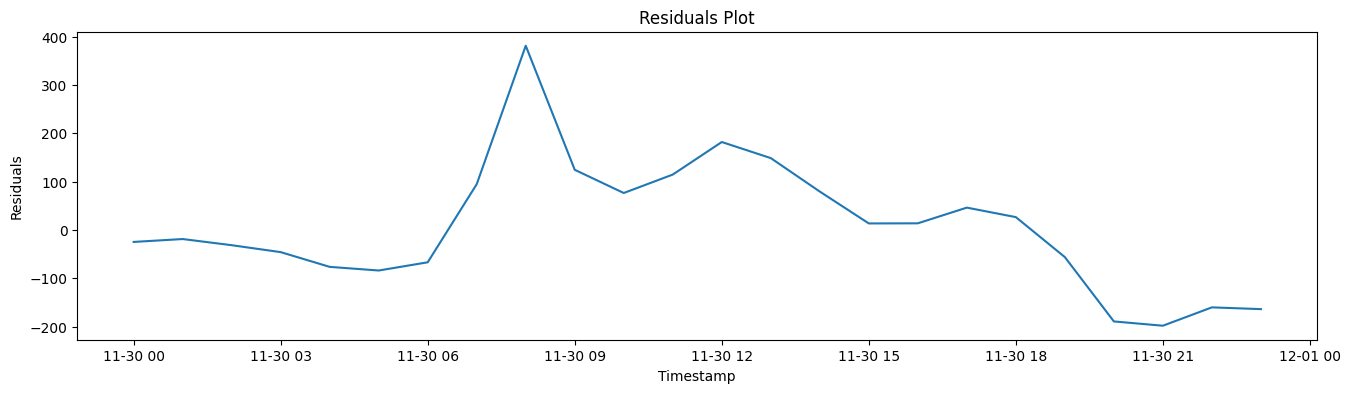

In [40]:
plt.figure(figsize=(16,4))
plt.plot(residuals_sarimax_with_exog_subset)
plt.ylabel("Residuals")
plt.xlabel("Timestamp")
plt.title("Residuals Plot")

Text(0, 0.5, 'Target')

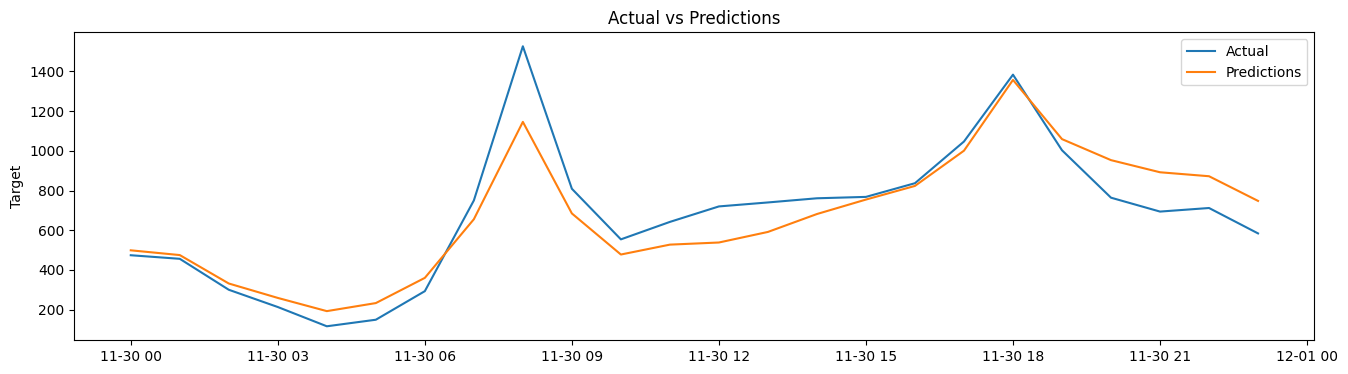

In [41]:
plt.figure(figsize=(16,4))
plt.plot(test_data["target"])
plt.plot(predictions_sarimax_with_exog_subset)
plt.legend(('Actual','Predictions'))
plt.title('Actual vs Predictions')
plt.ylabel('Target')

In [42]:
print('Mean Absolute Percent Error:', round(np.mean(abs(residuals_sarimax_with_exog_subset/test_data["target"])),4))
print('Root Mean Squared Error:', np.sqrt(np.mean(residuals_sarimax_with_exog_subset**2)))

Mean Absolute Percent Error: 0.1858
Root Mean Squared Error: 129.9479428736812


In [43]:
result_with_exog_subset=pd.DataFrame({"Actual":test_data["target"],"Predicted with Exog All":predictions_sarimax_with_exog_subset},index=test_data.index)
result_with_exog_subset

,Actual,Predicted with Exog All
Date,,
2018-11-30 00:00:00,474,498.785729
2018-11-30 01:00:00,456,474.812097
2018-11-30 02:00:00,300,331.542601
2018-11-30 03:00:00,213,258.872884
2018-11-30 04:00:00,116,192.366689
2018-11-30 05:00:00,149,232.887538
2018-11-30 06:00:00,293,359.919319
2018-11-30 07:00:00,750,655.331404
2018-11-30 08:00:00,1527,1145.991635


## The summary of the model with subset of features shows feature 'solar' has a very high p-value(0.873). We will remove this feature from the subset and re-train our model

In [44]:
exog_columns_subset1=copy.deepcopy(exog_columns_subset)
exog_columns_subset1.remove('rain')
exog_columns_subset1.remove('snow')

In [45]:
# With Exog Columns Subset excluding 'Rain' and 'Snow'
ts_model_sarimax_with_exog_subset1=SARIMAX(train_data["target"],order=non_seasonal_orders_with_exog_subset,seasonal_order=seasonal_orders_with_exog_subset,exog=train_data[exog_columns_subset1])

start=time()
model_fit_sarimax_with_exog_subset1=ts_model_sarimax_with_exog_subset1.fit()
end=time()
print("Model Fitting Time: ", end-start)
print(model_fit_sarimax_with_exog_subset1.summary())

Model Fitting Time:  39.24480485916138
                                     SARIMAX Results                                      
Dep. Variable:                             target   No. Observations:                 8735
Model:             SARIMAX(1, 1, 0)x(1, 0, 0, 24)   Log Likelihood              -59688.423
Date:                            Tue, 05 May 2026   AIC                         119390.846
Time:                                    18:33:17   BIC                         119440.371
Sample:                                12-01-2017   HQIC                        119407.723
                                     - 11-29-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
hum         -569.9875     35.371    -16.115      0.000    -639.313    -500.

In [46]:
predictions_sarimax_with_exog_subset1=model_fit_sarimax_with_exog_subset1.forecast(len(test_data),exog=test_data[exog_columns_subset1])
predictions_sarimax_with_exog_subset1=pd.Series(predictions_sarimax_with_exog_subset1,index=test_data.index)
residuals_sarimax_with_exog_subset1=test_data["target"]-predictions_sarimax_with_exog_subset1

Text(0.5, 1.0, 'Residuals Plot')

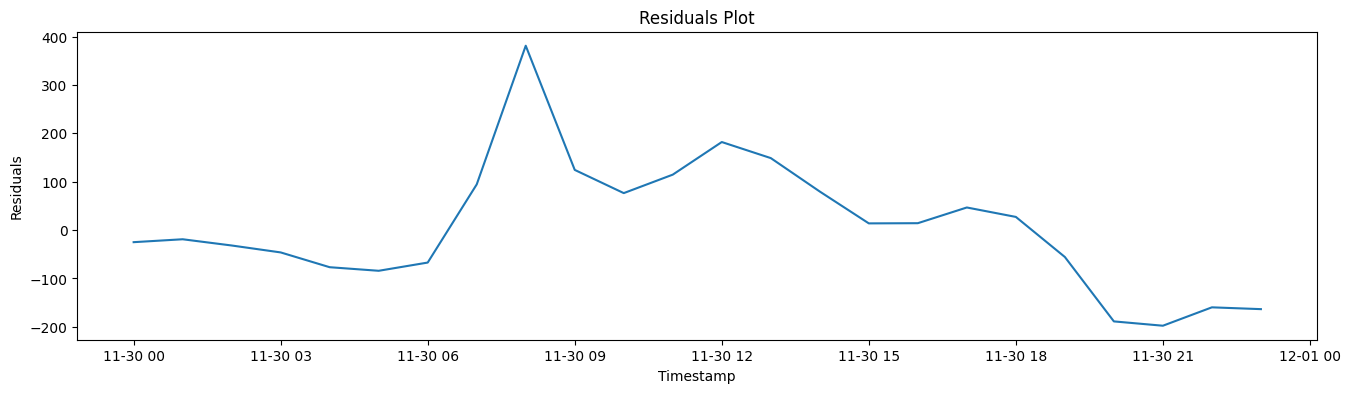

In [47]:
plt.figure(figsize=(16,4))
plt.plot(residuals_sarimax_with_exog_subset1)
plt.ylabel("Residuals")
plt.xlabel("Timestamp")
plt.title("Residuals Plot")

Text(0, 0.5, 'Target')

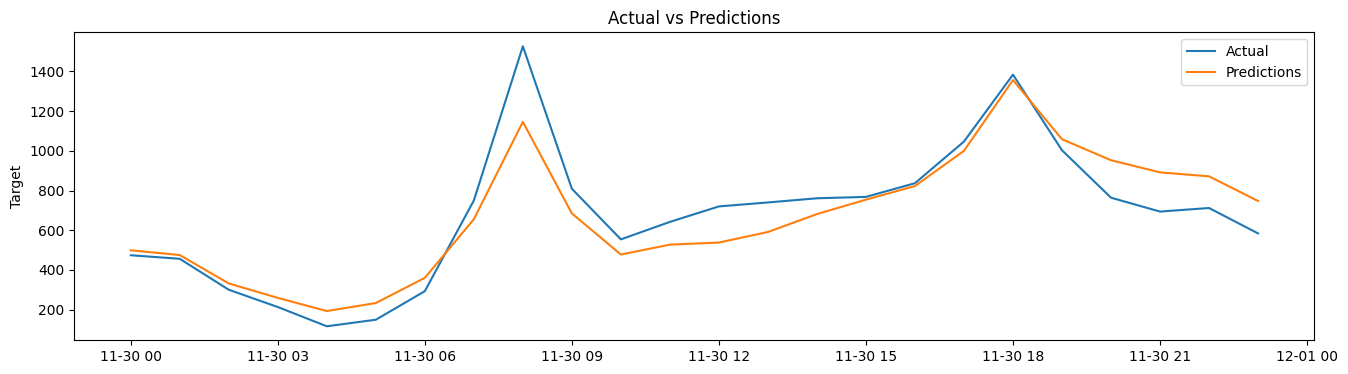

In [48]:
plt.figure(figsize=(16,4))
plt.plot(test_data["target"])
plt.plot(predictions_sarimax_with_exog_subset1)
plt.legend(('Actual','Predictions'))
plt.title('Actual vs Predictions')
plt.ylabel('Target')

In [49]:
print('Mean Absolute Percent Error:', round(np.mean(abs(residuals_sarimax_with_exog_subset1/test_data["target"])),4))
print('Root Mean Squared Error:', np.sqrt(np.mean(residuals_sarimax_with_exog_subset1**2)))

Mean Absolute Percent Error: 0.1861
Root Mean Squared Error: 129.88761630808506


## Best metrics got till now:  
Mean Absolute Percent Error: 0.1268  
Root Mean Squared Error: 69.04555448370564

In [50]:
result_with_exog_subset1=pd.DataFrame({"Actual":test_data["target"],"Predicted with Exog Subset 1":predictions_sarimax_with_exog_subset1},index=test_data.index)
result_with_exog_subset1

,Actual,Predicted with Exog Subset 1
Date,,
2018-11-30 00:00:00,474,498.923817
2018-11-30 01:00:00,456,474.918428
2018-11-30 02:00:00,300,331.790097
2018-11-30 03:00:00,213,259.122952
2018-11-30 04:00:00,116,192.675771
2018-11-30 05:00:00,149,233.062803
2018-11-30 06:00:00,293,360.067000
2018-11-30 07:00:00,750,655.541063
2018-11-30 08:00:00,1527,1145.988342


## Will try model selection using Lasso. First we fit Lasso using the exogenous variables and get a list of variables which are not equal to zero. We will use that list of variables in SARIMAX

In [51]:
alpha_values=[0.1,0.5,1,3,5,10,20,50,100]
for alpha in alpha_values:
  lasso_model=Lasso(alpha=alpha)
  lasso_model.fit(train_data[exog_columns],train_data['target'])
  predictions=lasso_model.predict(test_data[exog_columns])
  print("alpha=",alpha)
  lasso_model_coefs=[float(coef) for coef in lasso_model.coef_]
  lasso_model_coef_values=dict(zip(exog_columns,lasso_model_coefs))
  print("Lasso coefficients=",lasso_model_coef_values)
  print("R-squared=",r2_score(test_data['target'],predictions))
  print('***********************************************')

alpha= 0.1
Lasso coefficients= {'temp': 1725.707162645991, 'hum': -1164.7276418636554, 'wind': 469.7984226729091, 'vis': -24.39541022826799, 'dew': 241.26581215896047, 'solar': -413.0370121749236, 'rain': -1660.6572581490395, 'snow': 378.0845495982259, 'holiday': 134.03064556654368, 'func': 950.3266771013846, 's_autumn': 230.95014023151091, 's_spring': 81.06852411220751, 's_summer': -0.0, 's_winter': -67.85931053587414}
R-squared= 0.12087773623459241
***********************************************
alpha= 0.5
Lasso coefficients= {'temp': 1882.4066825463121, 'hum': -1028.7532420560242, 'wind': 434.50173375535485, 'vis': -5.52042082853352, 'dew': 0.0, 'solar': -379.4759956432813, 'rain': -1283.8770092953791, 'snow': 173.7139811649821, 'holiday': 125.26836309470355, 'func': 934.0580238772274, 's_autumn': 213.79448343039246, 's_spring': 64.69061666606133, 's_summer': -2.613601904940872, 's_winter': -85.62180793222133}
R-squared= 0.11860006993146865
******************************************

## With alpha=20 we got highest test R-squared. We will use the features selected by Lasso with alpha=20

In [52]:
exog_columns_subset2=['temp','hum','vis','func','s_winter']

In [53]:
# With Exog Columns after Lasso
ts_model_sarimax_with_exog_subset2=SARIMAX(train_data["target"],order=non_seasonal_orders_with_exog_subset,seasonal_order=seasonal_orders_with_exog_subset,exog=train_data[exog_columns_subset2])

start=time()
model_fit_sarimax_with_exog_subset2=ts_model_sarimax_with_exog_subset2.fit()
end=time()
print("Model Fitting Time: ", end-start)
print(model_fit_sarimax_with_exog_subset2.summary())

Model Fitting Time:  44.16975474357605
                                     SARIMAX Results                                      
Dep. Variable:                             target   No. Observations:                 8735
Model:             SARIMAX(1, 1, 0)x(1, 0, 0, 24)   Log Likelihood              -59259.787
Date:                            Tue, 05 May 2026   AIC                         118535.574
Time:                                    18:34:02   BIC                         118592.174
Sample:                                12-01-2017   HQIC                        118554.862
                                     - 11-29-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp        1091.4425    178.888      6.101      0.000     740.829    1442.

In [54]:
predictions_sarimax_with_exog_subset2=model_fit_sarimax_with_exog_subset2.forecast(len(test_data),exog=test_data[exog_columns_subset2])
predictions_sarimax_with_exog_subset2=pd.Series(predictions_sarimax_with_exog_subset2,index=test_data.index)
residuals_sarimax_with_exog_subset2=test_data["target"]-predictions_sarimax_with_exog_subset2

Text(0.5, 1.0, 'Residuals Plot')

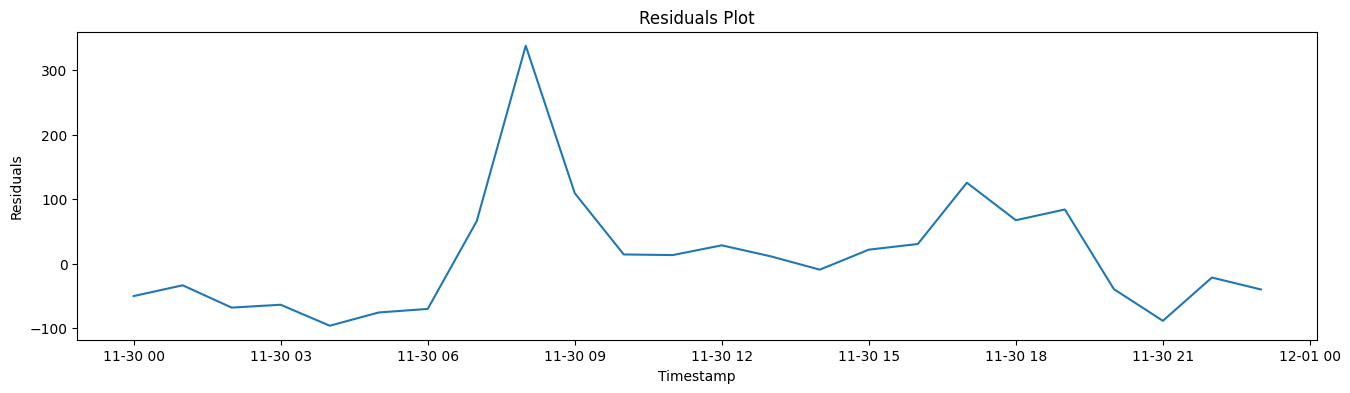

In [55]:
plt.figure(figsize=(16,4))
plt.plot(residuals_sarimax_with_exog_subset2)
plt.ylabel("Residuals")
plt.xlabel("Timestamp")
plt.title("Residuals Plot")

Text(0, 0.5, 'Target')

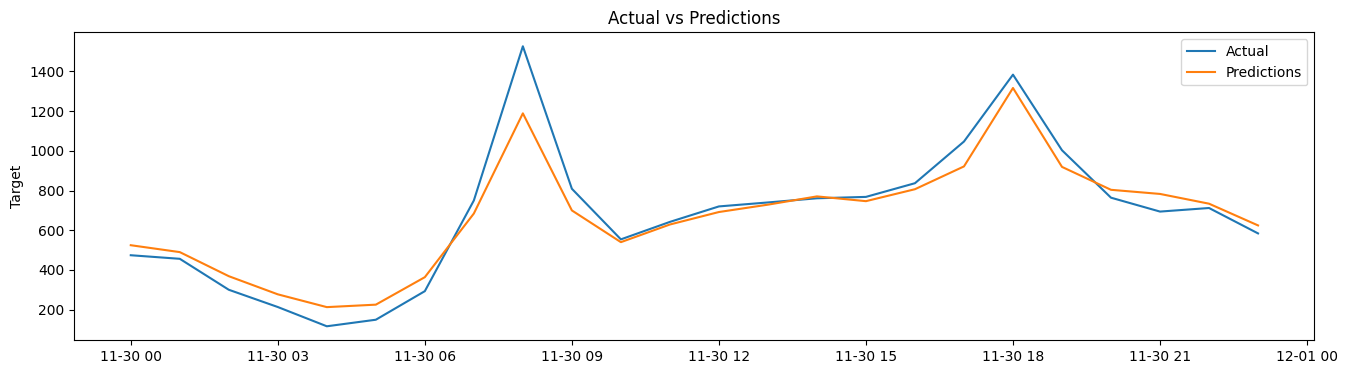

In [56]:
plt.figure(figsize=(16,4))
plt.plot(test_data["target"])
plt.plot(predictions_sarimax_with_exog_subset2)
plt.legend(('Actual','Predictions'))
plt.title('Actual vs Predictions')
plt.ylabel('Target')

In [57]:
print('Mean Absolute Percent Error:', round(np.mean(abs(residuals_sarimax_with_exog_subset2/test_data["target"])),4))
print('Root Mean Squared Error:', np.sqrt(np.mean(residuals_sarimax_with_exog_subset2**2)))

Mean Absolute Percent Error: 0.1435
Root Mean Squared Error: 92.33885609148716


In [58]:
result_with_exog_subset2=pd.DataFrame({"Actual":test_data["target"],"Predicted after Lasso":predictions_sarimax_with_exog_subset2},index=test_data.index)
result_with_exog_subset2

,Actual,Predicted after Lasso
Date,,
2018-11-30 00:00:00,474,524.522619
2018-11-30 01:00:00,456,489.763355
2018-11-30 02:00:00,300,368.410013
2018-11-30 03:00:00,213,276.982287
2018-11-30 04:00:00,116,212.525819
2018-11-30 05:00:00,149,224.954132
2018-11-30 06:00:00,293,363.463434
2018-11-30 07:00:00,750,684.238939
2018-11-30 08:00:00,1527,1188.990500


In [59]:
exog_columns_subset3=copy.deepcopy(exog_columns_subset2)
exog_columns_subset3.remove('s_winter')

In [60]:
# With Exog Columns after Lasso(removing 's_winter')
ts_model_sarimax_with_exog_subset3=SARIMAX(train_data["target"],order=non_seasonal_orders_with_exog_subset,seasonal_order=seasonal_orders_with_exog_subset,exog=train_data[exog_columns_subset3])

start=time()
model_fit_sarimax_with_exog_subset3=ts_model_sarimax_with_exog_subset3.fit()
end=time()
print("Model Fitting Time: ", end-start)
print(model_fit_sarimax_with_exog_subset3.summary())

Model Fitting Time:  38.77187156677246
                                     SARIMAX Results                                      
Dep. Variable:                             target   No. Observations:                 8735
Model:             SARIMAX(1, 1, 0)x(1, 0, 0, 24)   Log Likelihood              -59259.776
Date:                            Tue, 05 May 2026   AIC                         118533.552
Time:                                    18:34:41   BIC                         118583.077
Sample:                                12-01-2017   HQIC                        118550.430
                                     - 11-29-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
temp        1091.0803    178.886      6.099      0.000     740.470    1441.

In [61]:
predictions_sarimax_with_exog_subset3=model_fit_sarimax_with_exog_subset3.forecast(len(test_data),exog=test_data[exog_columns_subset3])
predictions_sarimax_with_exog_subset3=pd.Series(predictions_sarimax_with_exog_subset3,index=test_data.index)
residuals_sarimax_with_exog_subset3=test_data["target"]-predictions_sarimax_with_exog_subset3

In [62]:
print('Mean Absolute Percent Error:', round(np.mean(abs(residuals_sarimax_with_exog_subset3/test_data["target"])),4))
print('Root Mean Squared Error:', np.sqrt(np.mean(residuals_sarimax_with_exog_subset3**2)))

Mean Absolute Percent Error: 0.1435
Root Mean Squared Error: 92.33860996928026


In [63]:
train_data_rolling=train_data.copy()
rolling_preds=[]
rolling_confidence_intervals=[]
start=time()
for row in test_data.index:
  model_rolling=SARIMAX(train_data_rolling["target"],order=non_seasonal_orders_with_exog_subset,seasonal_order=seasonal_orders_with_exog_subset,exog=train_data_rolling[exog_columns_subset3])
  model_rolling_fit=model_rolling.fit()

  pred_details=model_rolling_fit.get_forecast(steps=1,exog=test_data.loc[row,exog_columns_subset3])
  rolling_preds.append(pred_details.predicted_mean.item())
  confidence_interval=pred_details.conf_int()
  rolling_confidence_intervals.append([0 if confidence_interval['lower target'][0]<0 else confidence_interval['lower target'][0].item(),confidence_interval['upper target'][0].item()])
  train_data_rolling=pd.concat([train_data_rolling,test_data.loc[[row]]])
end=time()
print("Time took to run: ", end-start)
print(rolling_confidence_intervals)

Time took to run:  922.5725274085999
[[105.35550857087406, 943.6610629444931], [13.477425745967878, 851.7373689916787], [0, 755.9371264593314], [0, 623.0962834130157], [0, 568.1655034401994], [0, 543.2137153933753], [0, 709.2297955520121], [195.4490083831373, 1033.4251100911324], [853.8504803692836, 1691.7991241664627], [654.3089647718625, 1492.290951728428], [199.8028275186669, 1037.7939092669587], [211.04033477717928, 1048.992685924923], [285.60917789469136, 1123.5139755317246], [339.998164112483, 1177.8558963423468], [360.4555937083398, 1198.2650344492258], [315.50303149387975, 1153.2648491077834], [413.362361903481, 1251.0773818533858], [534.6807078123577, 1372.3479231580893], [1035.9478177919098, 1873.5750791597186], [560.3409501118231, 1397.9182884219672], [470.7929521590317, 1308.3162538978463], [308.3168311858465, 1145.8066321869596], [219.61651192486846, 1057.0598735053604], [192.58704892098086, 1029.98792650226]]


In [64]:
result=pd.DataFrame(data={'actual':test_data['target'],'rolling_preds':rolling_preds,'rolling_residuals':test_data['target']-rolling_preds,'ci_lower':[row[0] for row in rolling_confidence_intervals],'ci_upper':[row[1] for row in rolling_confidence_intervals]},index=test_data.index)
print('Mean Absolute Percent Error:', round(np.mean(abs(result['rolling_residuals']/result['actual'])),4))
print('Root Mean Squared Error:', np.sqrt(np.mean(result['rolling_residuals']**2)))

Mean Absolute Percent Error: 0.0934
Root Mean Squared Error: 91.93873468389992


Text(0.5, 1.0, 'Rolling Residuals Plot')

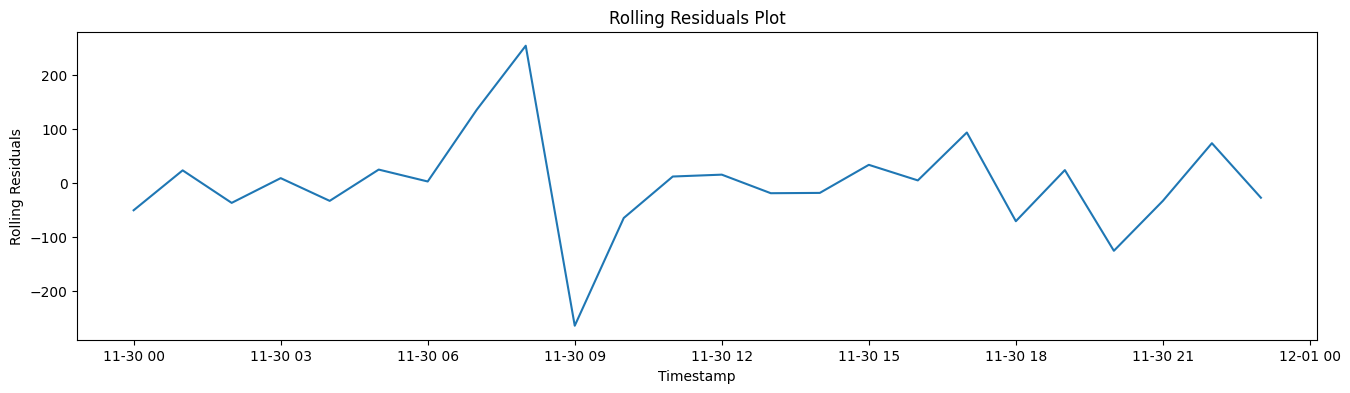

In [65]:
plt.figure(figsize=(16,4))
plt.plot(result['rolling_residuals'])
plt.ylabel("Rolling Residuals")
plt.xlabel("Timestamp")
plt.title("Rolling Residuals Plot")

Text(0, 0.5, 'First Differences')

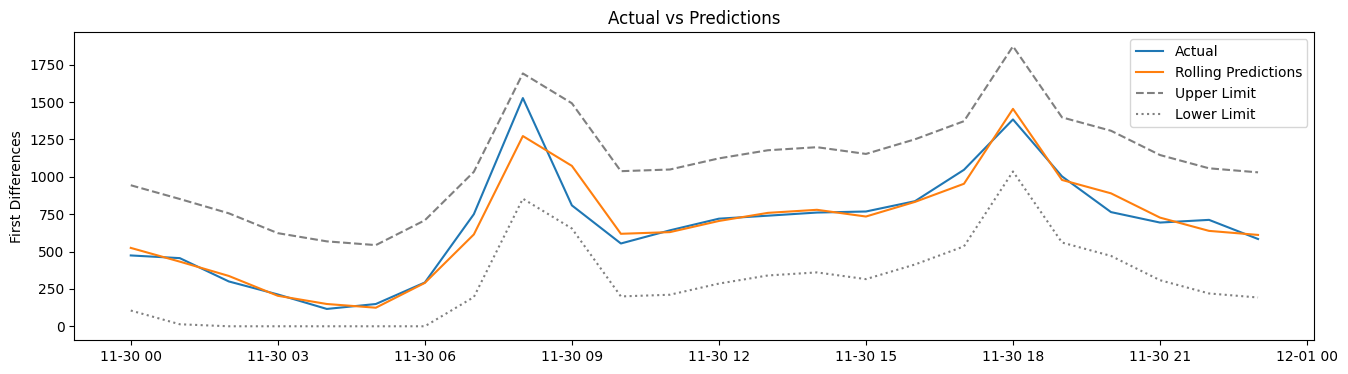

In [66]:
plt.figure(figsize=(16,4))
plt.plot(result["actual"])
plt.plot(result['rolling_preds'])
plt.plot(result['ci_upper'],linestyle='--',color='grey')
plt.plot(result['ci_lower'],linestyle=':',color='grey')
plt.legend(('Actual','Rolling Predictions','Upper Limit','Lower Limit'))
plt.title('Actual vs Predictions')
plt.ylabel('First Differences')

In [67]:
result

,actual,rolling_preds,rolling_residuals,ci_lower,ci_upper
Date,,,,,
2018-11-30 00:00:00,474,524.508286,-50.508286,105.355509,943.661063
2018-11-30 01:00:00,456,432.607397,23.392603,13.477426,851.737369
2018-11-30 02:00:00,300,336.830857,-36.830857,0.000000,755.937126
2018-11-30 03:00:00,213,204.013225,8.986775,0.000000,623.096283
2018-11-30 04:00:00,116,149.106297,-33.106297,0.000000,568.165503
2018-11-30 05:00:00,149,124.177958,24.822042,0.000000,543.213715
2018-11-30 06:00:00,293,290.217820,2.782180,0.000000,709.229796
2018-11-30 07:00:00,750,614.437059,135.562941,195.449008,1033.425110
2018-11-30 08:00:00,1527,1272.824802,254.175198,853.850480,1691.799124


In [68]:
model_fit_sarimax_with_exog_subset3.save("bike_sharing_ts_model_sarimax.pkl")